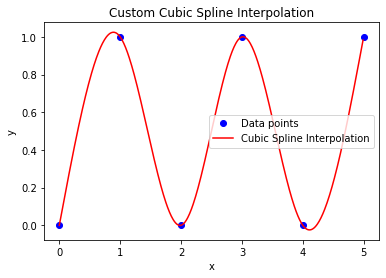

In [18]:
import numpy as np
import matplotlib.pyplot as plt


def setup_tridiagonal(h, y):
    n = len(h)
    a = np.zeros(n-1)
    b = np.zeros(n-1)
    c = np.zeros(n-1)
    d = np.zeros(n-1)
    for i in range(1, n):
        a[i-1] = h[i-1]
        b[i-1] = 2.0*(h[i-1]+h[i])
        c[i-1] = h[i]
        d[i-1] = 6.0*(((y[i+1]-y[i]) / h[i]) - ((y[i]-y[i-1]) / h[i-1]))
    return a, b, c, d


def solve_thomas(a, b, c, d):
    n = len(a)
    for i in range(1, n):
        w = a[i] / b[i-1]
        b[i] -= w * c[i-1]
        d[i] -= w * d[i-1]
    x = np.zeros(n)
    x[n-1] = d[n-1] / b[n-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i]*x[i+1]) / b[i]
    return x


def cubic_spline_interp(x, y):
    # Step 2: Calculate Step Sizes
    h = np.diff(x)

    # Step 3: Set Up and Solve the Tridiagonal System
    a, b, c, d = setup_tridiagonal(h, y)
    m = np.array([0.0, *solve_thomas(a, b, c, d), 0.0], dtype=float)

    # Step 4: Evaluate the Spline at New Points
    x2 = [np.arange(x[i], x[i+1], 0.01) for i in range(len(m)-1)]
    y2 = [*range(len(x2))]
    for i, xeval in enumerate(x2):
        th1 = 6.0 * h[i]
        th2 = h[i] / 6.0
        tx1 = x[i+1] - xeval
        tx2 = xeval - x[i]
        y2[i] = ((m[i]/th1)*(tx1**3)
                + (m[i+1]/th1)*(tx2**3)
                + ((y[i]/h[i])-(m[i]*th2))*tx1
                + ((y[i+1]/h[i])-(m[i+1]*th2))*tx2)
    x2 = np.hstack(x2)
    y2 = np.hstack(y2)
    return x2, y2


# Step 1: Define Known Data Points
x = np.array([0, 1, 2, 3, 4, 5], dtype=float)
y = np.array([0, 1, 0, 1, 0, 1], dtype=float)

# Interpolate
x2, y2 = cubic_spline_interp(x, y)

# Plot the Results
plt.plot(x, y, 'bo', label="Data points")
plt.plot(x2, y2, 'r-', label="Cubic Spline Interpolation")
plt.title("Custom Cubic Spline Interpolation")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()
